# Compression Neuronale vs JPEG

**Objectif** : Tester `bmshj2018_factorized` et `mbt2018_mean` (CompressAI) sur tous les niveaux de qualité (q=1 à 8),
comparer avec JPEG.

- Image test : région 10000x10000 extraite d'une lame SVS
- Modèles : poids pré-entraînés CompressAI 

In [24]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from io import BytesIO
import time

from compressai.zoo import bmshj2018_factorized, mbt2018_mean

In [25]:
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./outputs_10000')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DOCS_DIR = Path('../docs/static/images/learned_compression')
DOCS_DIR.mkdir(parents=True, exist_ok=True)

IMG_PATH = DATA_DIR / 'region_10000.png'
print(f'Image test: {IMG_PATH}')

Device: mps
Image test: data/region_10000.png


In [26]:
from PIL import PngImagePlugin

PngImagePlugin.MAX_TEXT_CHUNK = max(PngImagePlugin.MAX_TEXT_CHUNK, 1024 * 1024 * 1024)

def load_image(path):
    with Image.open(path) as img:
        img = img.convert('RGB')
        return np.array(img), img.size

img_np, (W, H) = load_image(IMG_PATH)
print(f'Taille: {W}×{H}, Shape: {img_np.shape}')
print(f'PNG original: {Path(IMG_PATH).stat().st_size / 1024:.0f} KB')

Taille: 10000×10000, Shape: (10000, 10000, 3)
PNG original: 103253 KB


In [27]:
def calculate_psnr(original, reconstructed):
    mse = np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    return 10 * np.log10(255.0 ** 2 / mse)

def calculate_bpp(likelihoods, num_pixels):
    total_bits = 0
    for key in likelihoods:
        bits = -torch.log2(likelihoods[key]).sum()
        total_bits += bits.item()
    return total_bits / num_pixels

def pad_to_multiple(tensor, multiple=64):
    _, _, h, w = tensor.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    if pad_h > 0 or pad_w > 0:
        tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode='reflect')
    return tensor, pad_h, pad_w

def crop_to_original(tensor, pad_h, pad_w):
    if pad_h > 0 or pad_w > 0:
        h = tensor.shape[2] - pad_h
        w = tensor.shape[3] - pad_w
        return tensor[:, :, :h, :w]
    return tensor

## 1. Benchmark JPEG (référence)

In [ ]:
jpeg_results = []

for quality in [10, 30, 50, 70, 90]:
    buf = BytesIO()
    img = Image.fromarray(img_np)
    img.save(buf, format='JPEG', quality=quality)
    size_bytes = buf.tell()
    buf.seek(0)
    jpeg_np = np.array(Image.open(buf).convert('RGB'))
    
    bpp = (size_bytes * 8) / (img_np.shape[0] * img_np.shape[1])
    psnr = calculate_psnr(img_np, jpeg_np)
    size_kb = size_bytes / 1024
    
    jpeg_results.append({
        'Méthode': 'JPEG',
        'Qualité': f'Q={quality}',
        'BPP': round(bpp, 4),
        'PSNR (dB)': round(psnr, 1),
        'Taille (KB)': round(size_kb, 0)
    })
    print(f'JPEG Q={quality:>2}  |  BPP={bpp:.4f}  |  PSNR={psnr:.1f} dB  |  {size_kb:.0f} KB')

In [31]:
TILE_SIZE = 4096  # réduit la mémoire par rapport à 5000

def run_tiled_inference_streaming(model, img_tensor, tile_size=TILE_SIZE, save_path=None):
    """Inférence tuile par tuile, libère la mémoire après chaque tuile.
    - Accumule le BPP sans garder le x_hat complet
    - Calcule le PSNR en streaming (somme des erreurs au carré)
    - Sauvegarde tuile par tuile sur disque pour la reconstruction finale
    """
    _, _, H, W = img_tensor.shape
    total_bits = 0.0
    sum_sq_err = 0.0

    n_tiles_h = (H + tile_size - 1) // tile_size
    n_tiles_w = (W + tile_size - 1) // tile_size

    if save_path:
        full_recon = np.zeros((H, W, 3), dtype=np.uint8)

    img_np_local = (img_tensor.squeeze(0).permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    for ty in range(n_tiles_h):
        for tx in range(n_tiles_w):
            y0 = ty * tile_size
            x0 = tx * tile_size
            y1 = min(y0 + tile_size, H)
            x1 = min(x0 + tile_size, W)

            tile = img_tensor[:, :, y0:y1, x0:x1]
            tile_padded, ph, pw = pad_to_multiple(tile, multiple=64)
            tile_padded = tile_padded.to(DEVICE)

            out = model(tile_padded)
            x_hat_tile = crop_to_original(out['x_hat'], ph, pw)
            x_hat_np = (x_hat_tile.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).clip(0, 255).astype(np.uint8)

            # BPP
            for key in out['likelihoods']:
                bits = -torch.log2(out['likelihoods'][key]).sum()
                total_bits += bits.item()

            # PSNR streaming
            orig_tile = img_np_local[y0:y1, x0:x1]
            sum_sq_err += np.sum((orig_tile.astype(np.float64) - x_hat_np.astype(np.float64)) ** 2)

            # Sauvegarde tuile
            if save_path:
                full_recon[y0:y1, x0:x1] = x_hat_np

            # Libérer mémoire MPS
            del out, x_hat_tile, tile_padded
            if DEVICE.type == 'mps':
                torch.mps.empty_cache()

    mse = sum_sq_err / (H * W * 3)
    psnr = 100.0 if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

    if save_path:
        Image.fromarray(full_recon).save(save_path)
        del full_recon

    return total_bits, psnr

## 2. Benchmark bmshj2018_factorized (q=1 à 8)

In [47]:
print('=== bmshj2018_factorized (TILING 4x4 sur MPS, streaming) ===')

bmshj_results = []
x = torch.from_numpy(img_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
num_pixels = img_np.shape[0] * img_np.shape[1]

for quality in range(1, 9):
    t0 = time.time()
    print(f'Loading bmshj2018_factorized q={quality}...', end=' ')
    model = bmshj2018_factorized(quality=quality, pretrained=True).eval().to(DEVICE)

    recon_path = OUTPUT_DIR / f'bmshj2018_q{quality}.png'
    with torch.no_grad():
        total_bits, psnr = run_tiled_inference_streaming(model, x, TILE_SIZE, recon_path)
        bpp = total_bits / num_pixels

    size_kb = bpp * num_pixels / 8 / 1024
    elapsed = time.time() - t0

    bmshj_results.append({
        'Méthode': 'bmshj2018_factorized',
        'Qualité': f'q={quality}',
        'BPP': round(bpp, 4),
        'PSNR (dB)': round(psnr, 2),
        'Taille (KB)': round(size_kb, 0)
    })

    print(f'BPP={bpp:.4f}  PSNR={psnr:.2f} dB  ({size_kb:.0f} KB)  [{elapsed:.1f}s]')
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    del model


=== bmshj2018_factorized (TILING 4x4 sur MPS, streaming) ===
Loading bmshj2018_factorized q=1... BPP=0.0771  PSNR=33.36 dB  (942 KB)  [17.9s]
Loading bmshj2018_factorized q=2... BPP=0.1128  PSNR=34.79 dB  (1377 KB)  [17.9s]
Loading bmshj2018_factorized q=3... BPP=0.1648  PSNR=35.99 dB  (2012 KB)  [17.6s]
Loading bmshj2018_factorized q=4... BPP=0.2415  PSNR=37.50 dB  (2948 KB)  [17.3s]
Loading bmshj2018_factorized q=5... BPP=0.3464  PSNR=39.07 dB  (4228 KB)  [17.8s]
Loading bmshj2018_factorized q=6... BPP=0.4806  PSNR=40.52 dB  (5867 KB)  [30.5s]
Loading bmshj2018_factorized q=7... BPP=0.6783  PSNR=42.34 dB  (8280 KB)  [31.2s]
Loading bmshj2018_factorized q=8... BPP=0.9442  PSNR=43.73 dB  (11526 KB)  [31.1s]


In [43]:
import torch
torch.mps.empty_cache()

In [51]:
print(f'MPS allocated: {torch.mps.current_allocated_memory() / 1e9:.2f} GB')
print(f'MPS driver allocated: {torch.mps.driver_allocated_memory() / 1e9:.2f} GB')

MPS allocated: 1.93 GB
MPS driver allocated: 9.35 GB


In [45]:
import gc
gc.collect()                          # nettoyer les refs Python
torch.mps.empty_cache()              # libérer le pool MPS
torch.mps.synchronize() 

## 3. Benchmark mbt2018_mean (q=1 à 8)

In [50]:
print('=== mbt2018_mean (TILING 4x4 sur MPS, streaming) ===')

mbt_results = []

for quality in range(1, 9):
    t0 = time.time()
    print(f'Loading mbt2018_mean q={quality}...', end=' ')
    model = mbt2018_mean(quality=quality, pretrained=True).eval().to(DEVICE)

    recon_path = OUTPUT_DIR / f'mbt2018_q{quality}.png'
    with torch.no_grad():
        total_bits, psnr = run_tiled_inference_streaming(model, x, TILE_SIZE, recon_path)
        bpp = total_bits / num_pixels

    size_kb = bpp * num_pixels / 8 / 1024
    elapsed = time.time() - t0

    mbt_results.append({
        'Méthode': 'mbt2018_mean',
        'Qualité': f'q={quality}',
        'BPP': round(bpp, 4),
        'PSNR (dB)': round(psnr, 2),
        'Taille (KB)': round(size_kb, 0)
    })

    print(f'BPP={bpp:.4f}  PSNR={psnr:.2f} dB  ({size_kb:.0f} KB)  [{elapsed:.1f}s]')
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    del model

print('mbt2018_mean terminé.')


=== mbt2018_mean (TILING 4x4 sur MPS, streaming) ===
Loading mbt2018_mean q=1... BPP=0.0350  PSNR=33.41 dB  (427 KB)  [20.9s]
Loading mbt2018_mean q=2... BPP=0.0567  PSNR=34.50 dB  (693 KB)  [20.5s]
Loading mbt2018_mean q=3... BPP=0.0909  PSNR=35.91 dB  (1110 KB)  [21.1s]
Loading mbt2018_mean q=4... BPP=0.1417  PSNR=37.28 dB  (1730 KB)  [18.7s]
Loading mbt2018_mean q=5... BPP=0.2105  PSNR=38.59 dB  (2570 KB)  [34.5s]
Loading mbt2018_mean q=6... BPP=0.3009  PSNR=40.63 dB  (3674 KB)  [32.3s]
Loading mbt2018_mean q=7... BPP=0.4373  PSNR=42.26 dB  (5339 KB)  [33.3s]
Loading mbt2018_mean q=8... BPP=0.6099  PSNR=43.72 dB  (7446 KB)  [34.8s]
mbt2018_mean terminé.


## 4. Résultats complets

In [52]:
df = pd.DataFrame(jpeg_results + bmshj_results + mbt_results)
print(f'\n=== Résultats ({len(df)} configurations) ===')

df_jpeg = df[df['Méthode'] == 'JPEG']
df_bmshj = df[df['Méthode'] == 'bmshj2018_factorized']
df_mbt = df[df['Méthode'] == 'mbt2018_mean']

print('\n--- JPEG ---')
display(df_jpeg[['Qualité', 'BPP', 'PSNR (dB)', 'Taille (KB)']].to_string(index=False))

print('\n--- bmshj2018_factorized ---')
display(df_bmshj[['Qualité', 'BPP', 'PSNR (dB)', 'Taille (KB)']].to_string(index=False))

print('\n--- mbt2018_mean ---')
display(df_mbt[['Qualité', 'BPP', 'PSNR (dB)', 'Taille (KB)']].to_string(index=False))

df.to_csv(OUTPUT_DIR / 'results_complete.csv', index=False)
print(f'\nRésultats sauvegardés: {OUTPUT_DIR / "results_complete.csv"}')


=== Résultats (21 configurations) ===

--- JPEG ---


'Qualité    BPP  PSNR (dB)  Taille (KB)\n   Q=10 0.1706       33.3       2083.0\n   Q=30 0.3309       37.6       4039.0\n   Q=50 0.4633       39.5       5656.0\n   Q=70 0.6611       41.4       8070.0\n   Q=90 1.3415       51.3      16376.0'


--- bmshj2018_factorized ---


'Qualité    BPP  PSNR (dB)  Taille (KB)\n    q=1 0.0771      33.36        942.0\n    q=2 0.1128      34.79       1377.0\n    q=3 0.1648      35.99       2012.0\n    q=4 0.2415      37.50       2948.0\n    q=5 0.3464      39.07       4228.0\n    q=6 0.4806      40.52       5867.0\n    q=7 0.6783      42.34       8280.0\n    q=8 0.9442      43.73      11526.0'


--- mbt2018_mean ---


'Qualité    BPP  PSNR (dB)  Taille (KB)\n    q=1 0.0350      33.41        427.0\n    q=2 0.0567      34.50        693.0\n    q=3 0.0909      35.91       1110.0\n    q=4 0.1417      37.28       1730.0\n    q=5 0.2105      38.59       2570.0\n    q=6 0.3009      40.63       3674.0\n    q=7 0.4373      42.26       5339.0\n    q=8 0.6099      43.72       7446.0'


Résultats sauvegardés: outputs_10000/results_complete.csv


## 5. Courbe

Courbe sauvegardée: outputs_10000/rate_distortion_curve.png
Copiée dans docs: ../docs/static/images/learned_compression/rate_distortion_curve.png


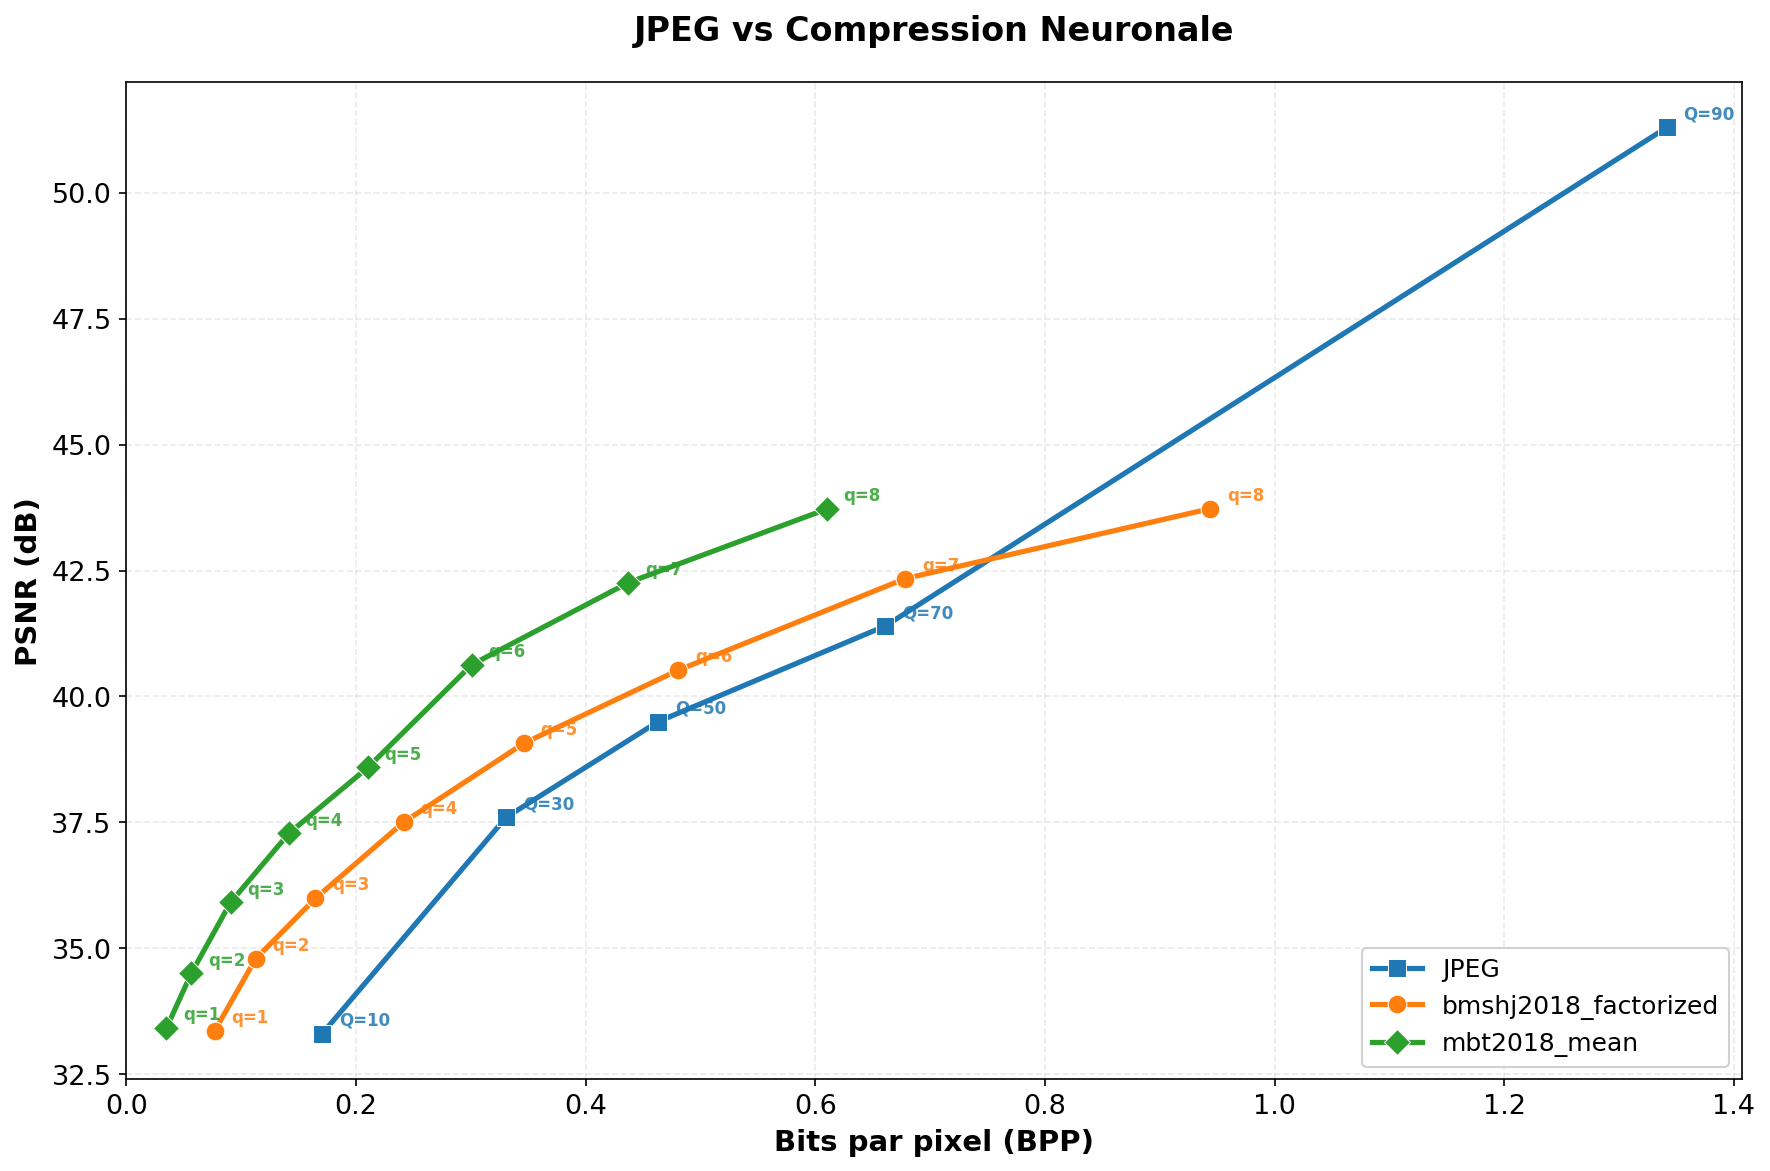

In [53]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'figure.dpi': 150
})

fig, ax = plt.subplots(figsize=(12, 8))

colors = {
    'JPEG': '#1f77b4',
    'bmshj2018_factorized': '#ff7f0e',
    'mbt2018_mean': '#2ca02c'
}

markers = {
    'JPEG': 's',
    'bmshj2018_factorized': 'o',
    'mbt2018_mean': 'D'
}

for method in ['JPEG', 'bmshj2018_factorized', 'mbt2018_mean']:
    subset = df[df['Méthode'] == method].sort_values('BPP')
    ax.plot(subset['BPP'], subset['PSNR (dB)'],
            marker=markers[method], linewidth=2.5, markersize=9,
            label=method, color=colors[method], markeredgewidth=0.5,
            markeredgecolor='white')
    
    # Annoter chaque point avec sa qualité
    for _, row in subset.iterrows():
        ax.annotate(row['Qualité'],
                    (row['BPP'], row['PSNR (dB)']),
                    textcoords='offset points',
                    xytext=(8, 4),
                    fontsize=8, fontweight='bold',
                    color=colors[method], alpha=0.85)

ax.set_xlabel('Bits par pixel (BPP)', fontweight='bold')
ax.set_ylabel('PSNR (dB)', fontweight='bold')
ax.set_title('JPEG vs Compression Neuronale',
             fontweight='bold', pad=20)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='#ccc')
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xlim(left=0)

plt.tight_layout()

curve_path = OUTPUT_DIR / 'rate_distortion_curve.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Courbe sauvegardée: {curve_path}')

# Copier dans les docs
import shutil
docs_path = DOCS_DIR / 'rate_distortion_curve.png'
shutil.copy(curve_path, docs_path)
print(f'Copiée dans docs: {docs_path}')

plt.show()

## 6. Comparaisons visuelles clés

On génère des images de comparaison pour les niveaux de qualité les plus pertinents (q=3 et q=5).

In [58]:
def save_comparison(recon_np, name, target_dir):
    """Sauvegarde la reconstruction en PNG pour les docs."""
    path = target_dir / f'{name}.png'
    Image.fromarray(recon_np).save(path)
    size_kb = path.stat().st_size / 1024
    print(f'  {path.name} ({size_kb:.0f} KB)')

print('=== Génération des images de comparaison pour les docs ===')

for q in [3, 5]:
    for model_name in ['bmshj2018', 'mbt2018']:
        src = OUTPUT_DIR / f'{model_name}_10000_q{q}.png'
        dst = DOCS_DIR / f'{model_name}_10000_q{q}.png'
        if src.exists():
            shutil.copy(src, dst)
            print(f'  {src.name} -> docs/')

# Sauvegarder aussi l'original en JPEG pour les docs
original_jpg = DOCS_DIR / 'region_10_000_original.jpg'
Image.fromarray(img_np).save(original_jpg, 'JPEG', quality=92)
print(f'  Original -> {original_jpg.name} ({original_jpg.stat().st_size/1024:.0f} KB)')

# JPEG Q=30 pour comparaison
jpeg30_path = DOCS_DIR / 'region_10_000_JPEG_Q30.jpg'
buf = BytesIO()
Image.fromarray(img_np).save(buf, format='JPEG', quality=30)
buf.seek(0)
Image.open(buf).save(jpeg30_path)
print(f'  JPEG Q=30 -> {jpeg30_path.name} ({jpeg30_path.stat().st_size/1024:.0f} KB)')

print('\nToutes les images sont dans docs/static/images/learned_compression/')

=== Génération des images de comparaison pour les docs ===
  Original -> region_10_000_original.jpg (16984 KB)
  JPEG Q=30 -> region_10_000_JPEG_Q30.jpg (5461 KB)

Toutes les images sont dans docs/static/images/learned_compression/


## 7. Résumé comparatif

In [55]:
print('=== MEILLEUR RAPPORT QUALITÉ/TAILLE ===')
print()

# Trouver le meilleur PSNR pour un BPP donné
for target_psnr in [32, 35, 38]:
    print(f'--- Proche de {target_psnr} dB ---')
    candidates = df[df['PSNR (dB)'].between(target_psnr - 1, target_psnr + 1)].sort_values('BPP')
    if not candidates.empty:
        best = candidates.iloc[0]
        print(f'  Meilleur: {best["Méthode"]} {best["Qualité"]}  |  BPP={best["BPP"]:.4f}  PSNR={best["PSNR (dB)"]:.1f} dB  |  {best["Taille (KB)"]:.0f} KB')
    print()

print('=== COMPARAISON mbt2018_mean vs bmshj2018_factorized ===')
for q in [1, 3, 5, 8]:
    b = df_bmshj[df_bmshj['Qualité'] == f'q={q}']
    m = df_mbt[df_mbt['Qualité'] == f'q={q}']
    if len(b) and len(m):
        b = b.iloc[0]
        m = m.iloc[0]
        print(f'q={q}: bmshj BPP={b["BPP"]:.4f} PSNR={b["PSNR (dB)"]:.1f}  |  mbt2018 BPP={m["BPP"]:.4f} PSNR={m["PSNR (dB)"]:.1f}')

=== MEILLEUR RAPPORT QUALITÉ/TAILLE ===

--- Proche de 32 dB ---

--- Proche de 35 dB ---
  Meilleur: mbt2018_mean q=2  |  BPP=0.0567  PSNR=34.5 dB  |  693 KB

--- Proche de 38 dB ---
  Meilleur: mbt2018_mean q=4  |  BPP=0.1417  PSNR=37.3 dB  |  1730 KB

=== COMPARAISON mbt2018_mean vs bmshj2018_factorized ===
q=1: bmshj BPP=0.0771 PSNR=33.4  |  mbt2018 BPP=0.0350 PSNR=33.4
q=3: bmshj BPP=0.1648 PSNR=36.0  |  mbt2018 BPP=0.0909 PSNR=35.9
q=5: bmshj BPP=0.3464 PSNR=39.1  |  mbt2018 BPP=0.2105 PSNR=38.6
q=8: bmshj BPP=0.9442 PSNR=43.7  |  mbt2018 BPP=0.6099 PSNR=43.7
